# OCR for Smart School Correction

This notebook builds an end-to-end optical character recognition (OCR) pipeline for the school correction project. We start from raw IDX image files, inspect the dataset, prepare the data, train a baseline model and a convolutional neural network, and finish with evaluation, error analysis, and an interactive drawing demo.

The notebook is organized so each section answers one question:
- What does the data look like?
- How do we preprocess it?
- Which model performs better?
- Where does the classifier still fail?

Use the outputs as a technical appendix for the final project report.


## Dataset Snapshot

Before training, we verify the dataset format and class structure.

- Images are grayscale `28 x 28` handwritten characters.
- There are `62` classes: digits, uppercase letters, and lowercase letters.
- The raw files are stored in IDX format, so we read them directly from the binary files.
- The notebook applies the same rotation and transpose convention as the project helper script so images appear in the correct orientation.
- We keep the original train/test split and later carve out a validation subset from the training data.

This section gives a compact technical overview of the data that drives the rest of the pipeline.


## 1. Environment and Imports

We import the numerical, plotting, and machine learning libraries needed for data loading, model training, and evaluation. This cell also sets up the display utilities used later in the notebook.


In [74]:
from pathlib import Path
import struct
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError as exc:
    raise ImportError(
        'TensorFlow is required for the CNN section. Run this notebook on Kaggle or install tensorflow.'
    ) from exc

tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.21.0
GPU available: False


## 2. Locate the Dataset

The notebook is designed to run in multiple environments, including the local project folder and Kaggle. The following helper scans a small list of known locations and selects the first path that exists.


In [75]:
# Locate the dataset whether the notebook is run from Project2026/ or the repo root.
DATA_DIR_CANDIDATES = [
    Path('data/project_2026_dataset/student_dataset/image_data'),
    Path('Project2026/data/project_2026_dataset/student_dataset/image_data'),
    Path('../input/project_2026_dataset/student_dataset/image_data'),
    Path('/kaggle/input/project_2026_dataset/student_dataset/image_data'),
    Path('/kaggle/input/project-2026-dataset/student_dataset/image_data'),
]

def find_data_dir():
    for candidate in DATA_DIR_CANDIDATES:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find the OCR dataset directory.')


DATA_DIR = find_data_dir()
MAPPING_PATH = DATA_DIR / 'mapping.txt'
TRAIN_IMAGES_PATH = DATA_DIR / 'train-images-idx3-ubyte'
TRAIN_LABELS_PATH = DATA_DIR / 'train-labels-idx1-ubyte'
TEST_IMAGES_PATH = DATA_DIR / 'test-images-idx3-ubyte'
TEST_LABELS_PATH = DATA_DIR / 'test-labels-idx1-ubyte'

def load_mapping(path):
    mapping = {}
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            idx_str, ascii_str = line.split()
            mapping[int(idx_str)] = chr(int(ascii_str))
    return mapping


def load_idx_images(path):
    with path.open('rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f'Unexpected image magic number: {magic}')
        images = np.frombuffer(f.read(), dtype=np.uint8)
    images = images.reshape(num, rows, cols)
    # Match the orientation used by the helper script shipped with the project.
    return np.transpose(images, (0, 2, 1)).copy()


def load_idx_labels(path):
    with path.open('rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        if magic != 2049:
            raise ValueError(f'Unexpected label magic number: {magic}')
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)


mapping = load_mapping(MAPPING_PATH)
label_names = [mapping[i] for i in range(len(mapping))]
num_classes = len(label_names)

print('Data directory:', DATA_DIR)
print('Classes:', num_classes)
print('First 15 labels:', label_names[:15])


Data directory: data/project_2026_dataset/student_dataset/image_data
Classes: 62
First 15 labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E']


## 3. Load and Summarize the Data

Here we load the IDX image and label files, then compute a compact summary of the train and test splits. This gives an early check on sample counts, image shapes, and label balance.

we then split the dataset between train and test components.


In [76]:
x_train_raw = load_idx_images(TRAIN_IMAGES_PATH)
y_train_raw = load_idx_labels(TRAIN_LABELS_PATH)
x_test_raw = load_idx_images(TEST_IMAGES_PATH)
y_test_raw = load_idx_labels(TEST_LABELS_PATH)

train_counts = np.bincount(y_train_raw, minlength=num_classes)
test_counts = np.bincount(y_test_raw, minlength=num_classes)

summary = pd.DataFrame({
    'split': ['train', 'test'],
    'n_samples': [len(y_train_raw), len(y_test_raw)],
    'image_shape': [str(x_train_raw.shape[1:]), str(x_test_raw.shape[1:])],
    'n_classes': [len(np.unique(y_train_raw)), len(np.unique(y_test_raw))],
    'pixel_min': [int(x_train_raw.min()), int(x_test_raw.min())],
    'pixel_max': [int(x_train_raw.max()), int(x_test_raw.max())],
    'pixel_mean': [float(x_train_raw.mean()), float(x_test_raw.mean())],
    'pixel_std': [float(x_train_raw.std()), float(x_test_raw.std())],
})

display(summary)
print('Any missing labels in train?', np.isnan(y_train_raw).any())
print('Any missing labels in test?', np.isnan(y_test_raw).any())
top_train = train_counts.argsort()[::-1][:10]
print('Top 10 train classes:', [(label_names[idx], int(train_counts[idx])) for idx in top_train])


,split,n_samples,image_shape,n_classes,pixel_min,pixel_max,pixel_mean,pixel_std
0,train,697932,"(28, 28)",62,0,255,44.266017,84.571172
1,test,116323,"(28, 28)",62,0,255,44.271084,84.571629


Any missing labels in train? False
Any missing labels in test? False
Top 10 train classes: [('1', 38374), ('7', 35754), ('3', 35143), ('0', 34585), ('6', 34232), ('2', 34203), ('8', 33946), ('9', 33847), ('4', 33535), ('5', 31416)]


## 4. Visual Inspection

A few sample images help confirm that preprocessing is correct and that labels match the handwritten characters. Visual checks are especially useful for OCR because they expose orientation issues, noise, and ambiguous classes.


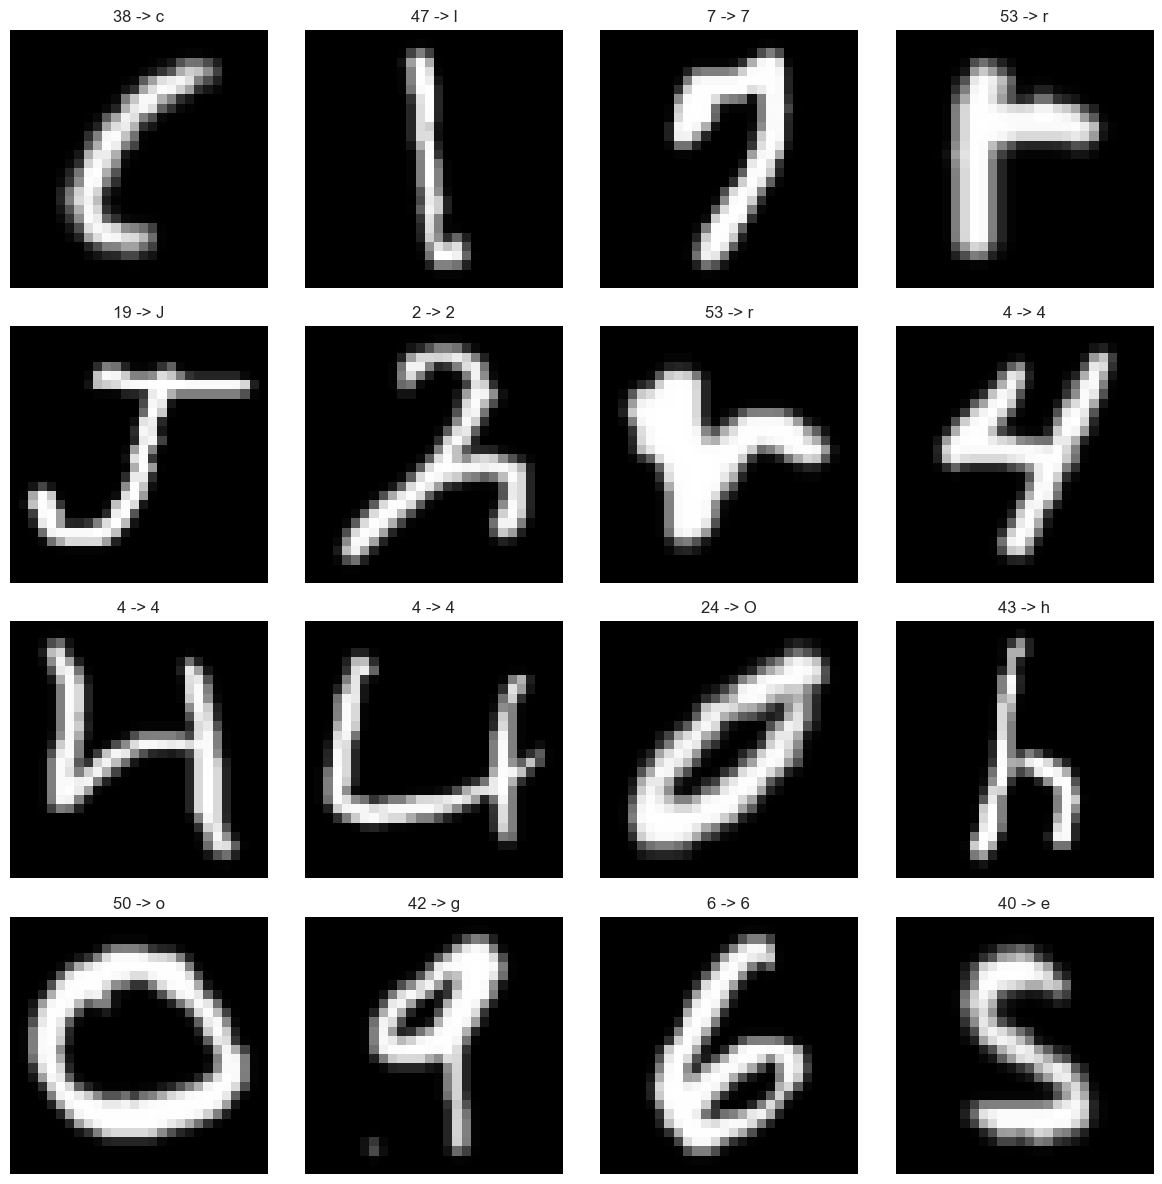

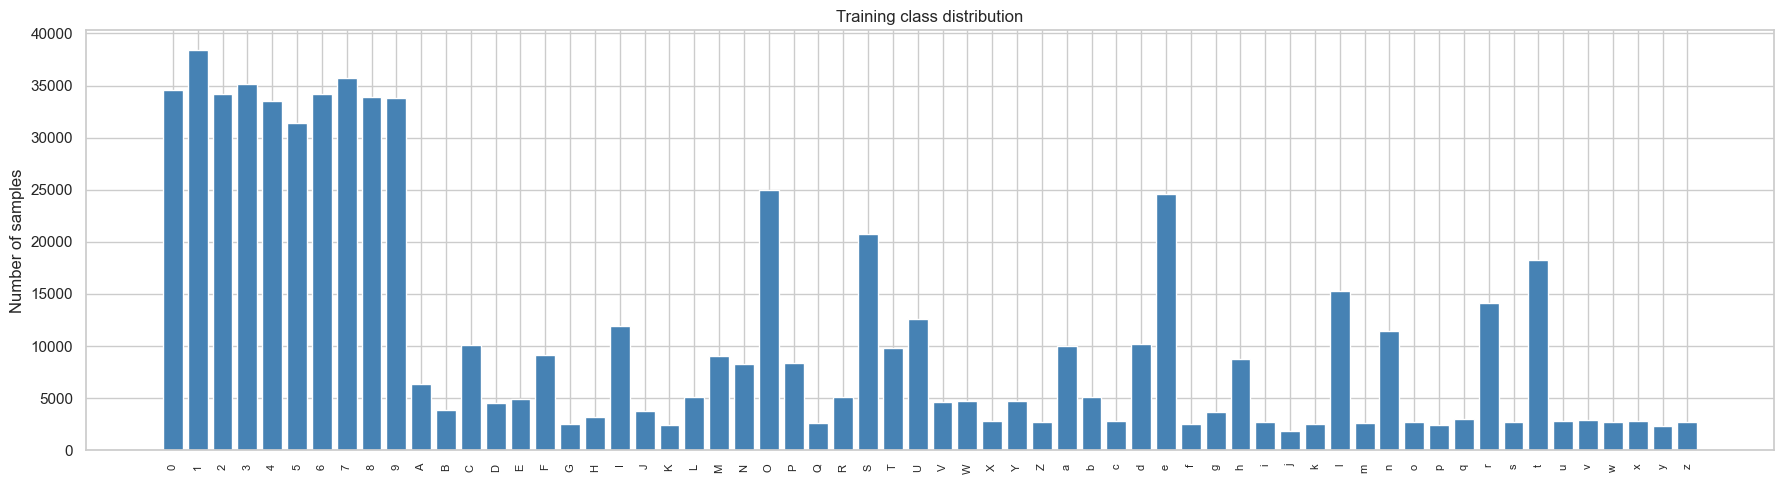

In [77]:
def show_samples(images, labels, names, n=16, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(labels), size=n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, sample_idx in zip(axes, idx):
        ax.imshow(images[sample_idx], cmap='gray')
        ax.set_title(f"{labels[sample_idx]} -> {names[int(labels[sample_idx])]}")
        ax.axis('off')
    for ax in axes[len(idx):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_samples(x_train_raw, y_train_raw, label_names, n=16)

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(np.arange(num_classes), train_counts, color='steelblue')
ax.set_xticks(np.arange(num_classes))
ax.set_xticklabels(label_names, rotation=90, fontsize=8)
ax.set_title('Training class distribution')
ax.set_ylabel('Number of samples')
plt.tight_layout()
plt.show()


## 5. Preprocessing and Sampling Strategy

The full training set is large, so the notebook supports optional subsampling for faster iteration. We also reserve a validation split from the training portion so we can compare models without touching the held-out test set.

Key steps in this section:
- normalize and reshape the images
- create train, validation, and test subsets
- keep class proportions stable through stratified sampling


In [105]:
# Set these to None if you want to run on the full splits.
# The defaults keep the notebook practical for local iteration while still using a large sample.
TRAIN_LIMIT = 120_000
TEST_LIMIT = 20_000
VALIDATION_SIZE = 0.15

def sample_indices(y, limit, random_state=42):
    idx = np.arange(len(y))
    if limit is None or limit >= len(idx):
        return idx
    sampled, _ = train_test_split(idx, train_size=limit, stratify=y, random_state=random_state)
    return np.sort(sampled)


train_idx = sample_indices(y_train_raw, TRAIN_LIMIT)
test_idx = sample_indices(y_test_raw, TEST_LIMIT)

x_train_subset = x_train_raw[train_idx].astype('float32') / 255.0
y_train_subset = y_train_raw[train_idx]
x_test_subset = x_test_raw[test_idx].astype('float32') / 255.0
y_test_subset = y_test_raw[test_idx]


def build_foreground_mask(images, threshold=0.02, dilation=3):
    images = np.asarray(images, dtype=np.float32)
    single_image = images.ndim == 2
    if single_image:
        images = images[None, ...]
    binary = (images > threshold).astype(np.float32)[..., np.newaxis]
    dilated = tf.nn.max_pool2d(binary, ksize=dilation, strides=1, padding='SAME')
    softened = tf.nn.avg_pool2d(dilated, ksize=3, strides=1, padding='SAME').numpy()[..., 0]
    mask = np.maximum(softened, images)
    mask = np.clip(mask, 0.0, 1.0)
    return mask[0] if single_image else mask


def prepare_cnn_input(images):
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 2:
        masks = build_foreground_mask(images)
        return np.stack([images, masks], axis=-1)

    if images.ndim != 3:
        raise ValueError(f'Expected a 2D image or a 3D batch, got shape {images.shape}')

    masks = build_foreground_mask(images)
    return np.stack([images, masks], axis=-1)


x_train, x_val, y_train, y_val = train_test_split(
    x_train_subset,
    y_train_subset,
    test_size=VALIDATION_SIZE,
    stratify=y_train_subset,
    random_state=42,
)

x_train_cnn = prepare_cnn_input(x_train)
x_val_cnn = prepare_cnn_input(x_val)
x_test_cnn = prepare_cnn_input(x_test_subset)

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_val.shape, y_val.shape)
print('Test:', x_test_subset.shape, y_test_subset.shape)
print('CNN input shape:', x_train_cnn.shape)
print('Pixel range after normalization:', float(x_train.min()), float(x_train.max()))


Train: (102000, 28, 28) (102000,)
Validation: (18000, 28, 28) (18000,)
Test: (20000, 28, 28) (20000,)
CNN input shape: (102000, 28, 28, 2)
Pixel range after normalization: 0.0 1.0


## 6. Baseline Model

We start with a lightweight linear classifier on flattened pixels. This baseline is intentionally simple: it trains quickly and gives us a reference point before moving to the convolutional model.

If the CNN does not improve meaningfully over this baseline, that is an important signal that the model or preprocessing pipeline needs attention.


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.506889,0.448364,0.432500,0.382893
1,test,0.504600,0.441273,0.426856,0.374214


              precision    recall  f1-score   support

           0       0.63      0.53      0.57       993
           1       0.59      0.49      0.54      1088
           2       0.89      0.55      0.68      1009
           3       0.81      0.86      0.83      1026
           4       0.91      0.37      0.53       966
           5       0.74      0.54      0.62       892
           6       0.82      0.80      0.81       981
           7       0.95      0.81      0.88      1056
           8       0.89      0.48      0.63       969
           9       0.86      0.68      0.76       978
           A       0.36      0.54      0.43       183
           B       0.24      0.37      0.29       111
           C       0.47      0.44      0.45       299
           D       0.15      0.65      0.25       134
           E       0.82      0.25      0.38       146
           F       0.48      0.10      0.17       248
           G       0.23      0.44      0.30        77
           H       0.48    

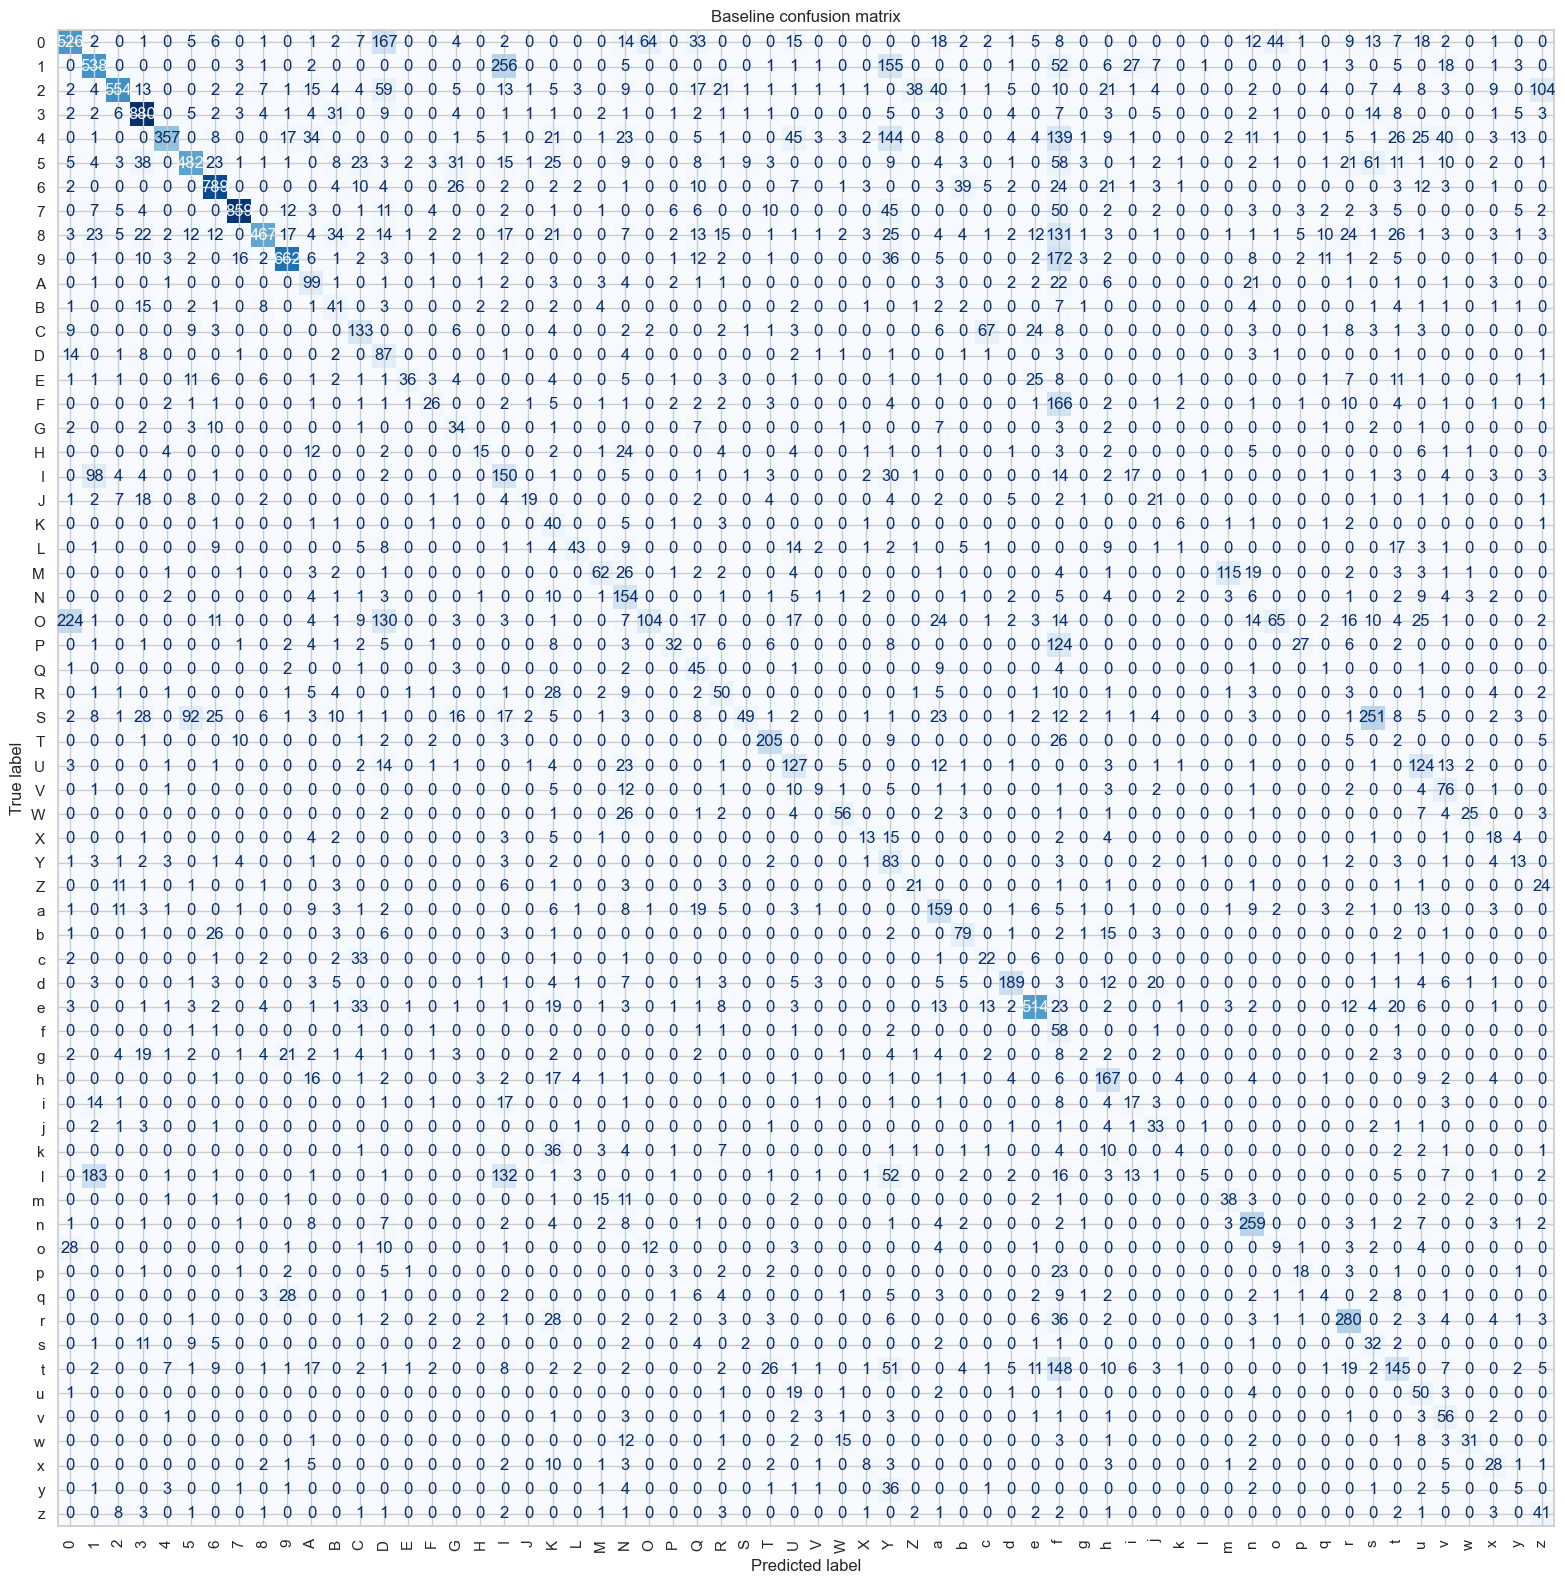

In [79]:
# Baseline: simple linear classifier on flattened pixels.
# This gives a fast reference point before the CNN.
x_train_flat = x_train.reshape(len(x_train), -1)
x_val_flat = x_val.reshape(len(x_val), -1)
x_test_flat = x_test_subset.reshape(len(x_test_subset), -1)

baseline = SGDClassifier(
    loss='log_loss',
    alpha=1e-5,
    max_iter=20,
    tol=1e-3,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
baseline.fit(x_train_flat, y_train)

val_baseline_pred = baseline.predict(x_val_flat)
test_baseline_pred = baseline.predict(x_test_flat)

baseline_metrics = {
    'split': ['validation', 'test'],
    'accuracy': [accuracy_score(y_val, val_baseline_pred), accuracy_score(y_test_subset, test_baseline_pred)],
    'precision_macro': [precision_score(y_val, val_baseline_pred, average='macro', zero_division=0), precision_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
    'recall_macro': [recall_score(y_val, val_baseline_pred, average='macro', zero_division=0), recall_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
    'f1_macro': [f1_score(y_val, val_baseline_pred, average='macro', zero_division=0), f1_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
}

display(pd.DataFrame(baseline_metrics))
print(classification_report(y_test_subset, test_baseline_pred, target_names=label_names, zero_division=0))

cm_baseline = confusion_matrix(y_test_subset, test_baseline_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.0f')
plt.xticks(rotation=90)
plt.title('Baseline confusion matrix')
plt.tight_layout()
plt.show()


## 7. Convolutional Neural Network

The main model is a CNN, which can learn spatial patterns such as strokes, curves, and intersections directly from the image grid. Compared with the linear baseline, it is better suited to handwritten character recognition.

This version adds light augmentation, a deeper convolutional stack, spatial dropout, and a two-channel input: the grayscale image plus a soft foreground mask that keeps the character and its gray contours. It still uses the same stability ideas as the failure-prediction project: early stopping and learning-rate reduction.


In [80]:
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(cls): float(weight)
                     for cls, weight in zip(np.unique(y_train), class_weights)}

keras.backend.clear_session()

data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(0.08, 0.08, fill_mode='nearest'),
    keras.layers.RandomRotation(0.06, fill_mode='nearest'),
    # 0.10 → 0.05, trop agressif sur 28x28
    keras.layers.RandomZoom(0.05, 0.05, fill_mode='nearest'),
], name='data_augmentation')

cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 2)),
    data_augmentation,

    # Bloc 1 — features simples, 32 filtres suffisent à ce stade
    keras.layers.Conv2D(32, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.SpatialDropout2D(0.10),

    # Bloc 2 — 14x14, on monte à 64
    keras.layers.Conv2D(64, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    # double bloc justifié ici
    keras.layers.Conv2D(64, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.SpatialDropout2D(0.20),

    # Bloc 3 — 7x7, features complexes
    keras.layers.Conv2D(128, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),

    # Tête de classification
    # produit 128 valeurs, pas besoin de Dense cachée
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(num_classes, activation='softmax'),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]

history = cnn.fit(
    x_train_cnn,
    y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=50,                # les callbacks gèrent l'arrêt
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50


W0000 00:00:1778439977.564369 1559512 cpu_allocator_impl.cc:82] Allocation of 639744000 exceeds 10% of free system memory.


399/399 ━━━━━━━━━━━━━━━━━━━━ 131s 321ms/step - accuracy: 0.1471 - loss: 3.5138 - val_accuracy: 0.2391 - val_loss: 3.0538 - learning_rate: 5.0000e-04
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 133s 333ms/step - accuracy: 0.3861 - loss: 2.2435 - val_accuracy: 0.7162 - val_loss: 1.1266 - learning_rate: 5.0000e-04
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 130s 325ms/step - accuracy: 0.5061 - loss: 1.6820 - val_accuracy: 0.7442 - val_loss: 0.8901 - learning_rate: 5.0000e-04
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 123s 307ms/step - accuracy: 0.5663 - loss: 1.4177 - val_accuracy: 0.7556 - val_loss: 0.7554 - learning_rate: 5.0000e-04
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 125s 313ms/step - accuracy: 0.5979 - loss: 1.2702 - val_accuracy: 0.7628 - val_loss: 0.7234 - learning_rate: 5.0000e-04
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 129s 323ms/step - accuracy: 0.6260 - loss: 1.1687 - val_accuracy: 0.7687 - val_loss: 0.6751 - learning_rate: 5.0000e-04
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 128s 322ms/

## 8. Training Curves

After training, we inspect the loss and accuracy curves to understand convergence behavior. A healthy fit should show training and validation metrics moving in the same direction without a large gap.


,accuracy,loss,val_accuracy,val_loss,learning_rate
32,0.738441,0.746697,0.800500,0.540627,0.000125
33,0.741735,0.732753,0.796111,0.544276,0.000063
34,0.740451,0.735353,0.801111,0.537309,0.000063
35,0.741490,0.730421,0.801056,0.538890,0.000063
36,0.741882,0.726568,0.802000,0.535981,0.000031


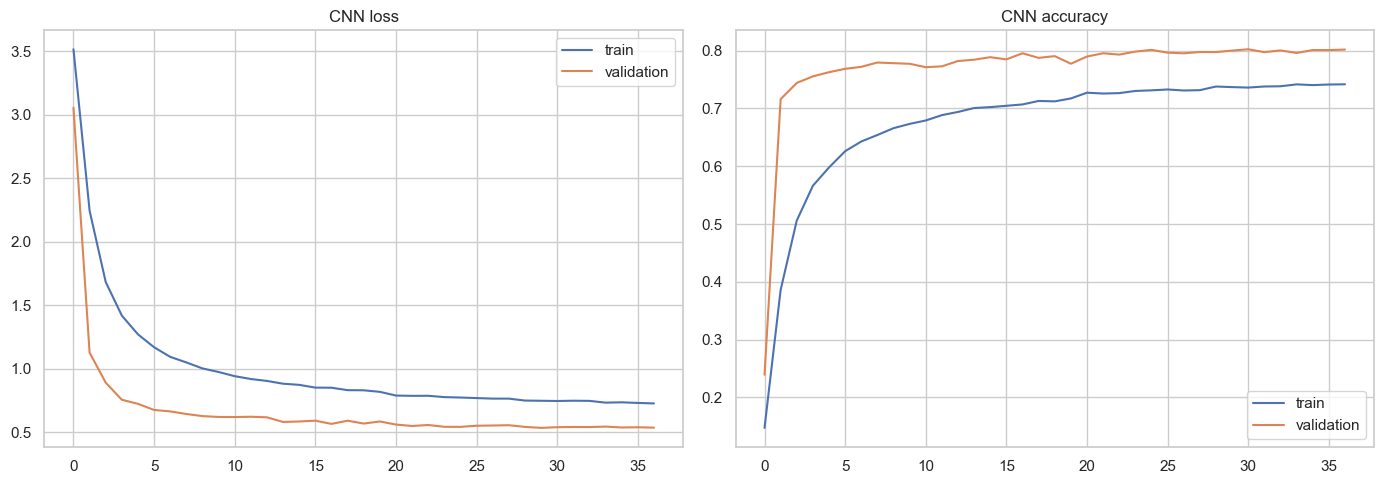

In [81]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['loss'], label='train')
axes[0].plot(history_df['val_loss'], label='validation')
axes[0].set_title('CNN loss')
axes[0].legend()

axes[1].plot(history_df['accuracy'], label='train')
axes[1].plot(history_df['val_accuracy'], label='validation')
axes[1].set_title('CNN accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Final Evaluation

We evaluate the selected model on the held-out test split using accuracy, precision, recall, and F1-score. This is the main quantitative result for the OCR system.

The confusion matrix helps identify which characters are most often confused and whether the mistakes are concentrated among visually similar classes.


,split,accuracy,precision_macro,recall_macro,f1_macro
0,test,0.8016,0.705899,0.761814,0.712752


              precision    recall  f1-score   support

           0       0.69      0.72      0.71       993
           1       0.71      0.67      0.69      1088
           2       0.97      0.82      0.89      1009
           3       1.00      0.98      0.99      1026
           4       0.99      0.91      0.95       966
           5       0.93      0.93      0.93       892
           6       0.99      0.92      0.95       981
           7       0.98      0.97      0.98      1056
           8       0.99      0.94      0.96       969
           9       0.95      0.93      0.94       978
           A       0.89      0.97      0.93       183
           B       0.77      0.97      0.86       111
           C       0.81      0.37      0.51       299
           D       0.73      0.96      0.83       134
           E       0.92      0.97      0.94       146
           F       0.85      0.54      0.66       248
           G       0.67      1.00      0.80        77
           H       0.74    

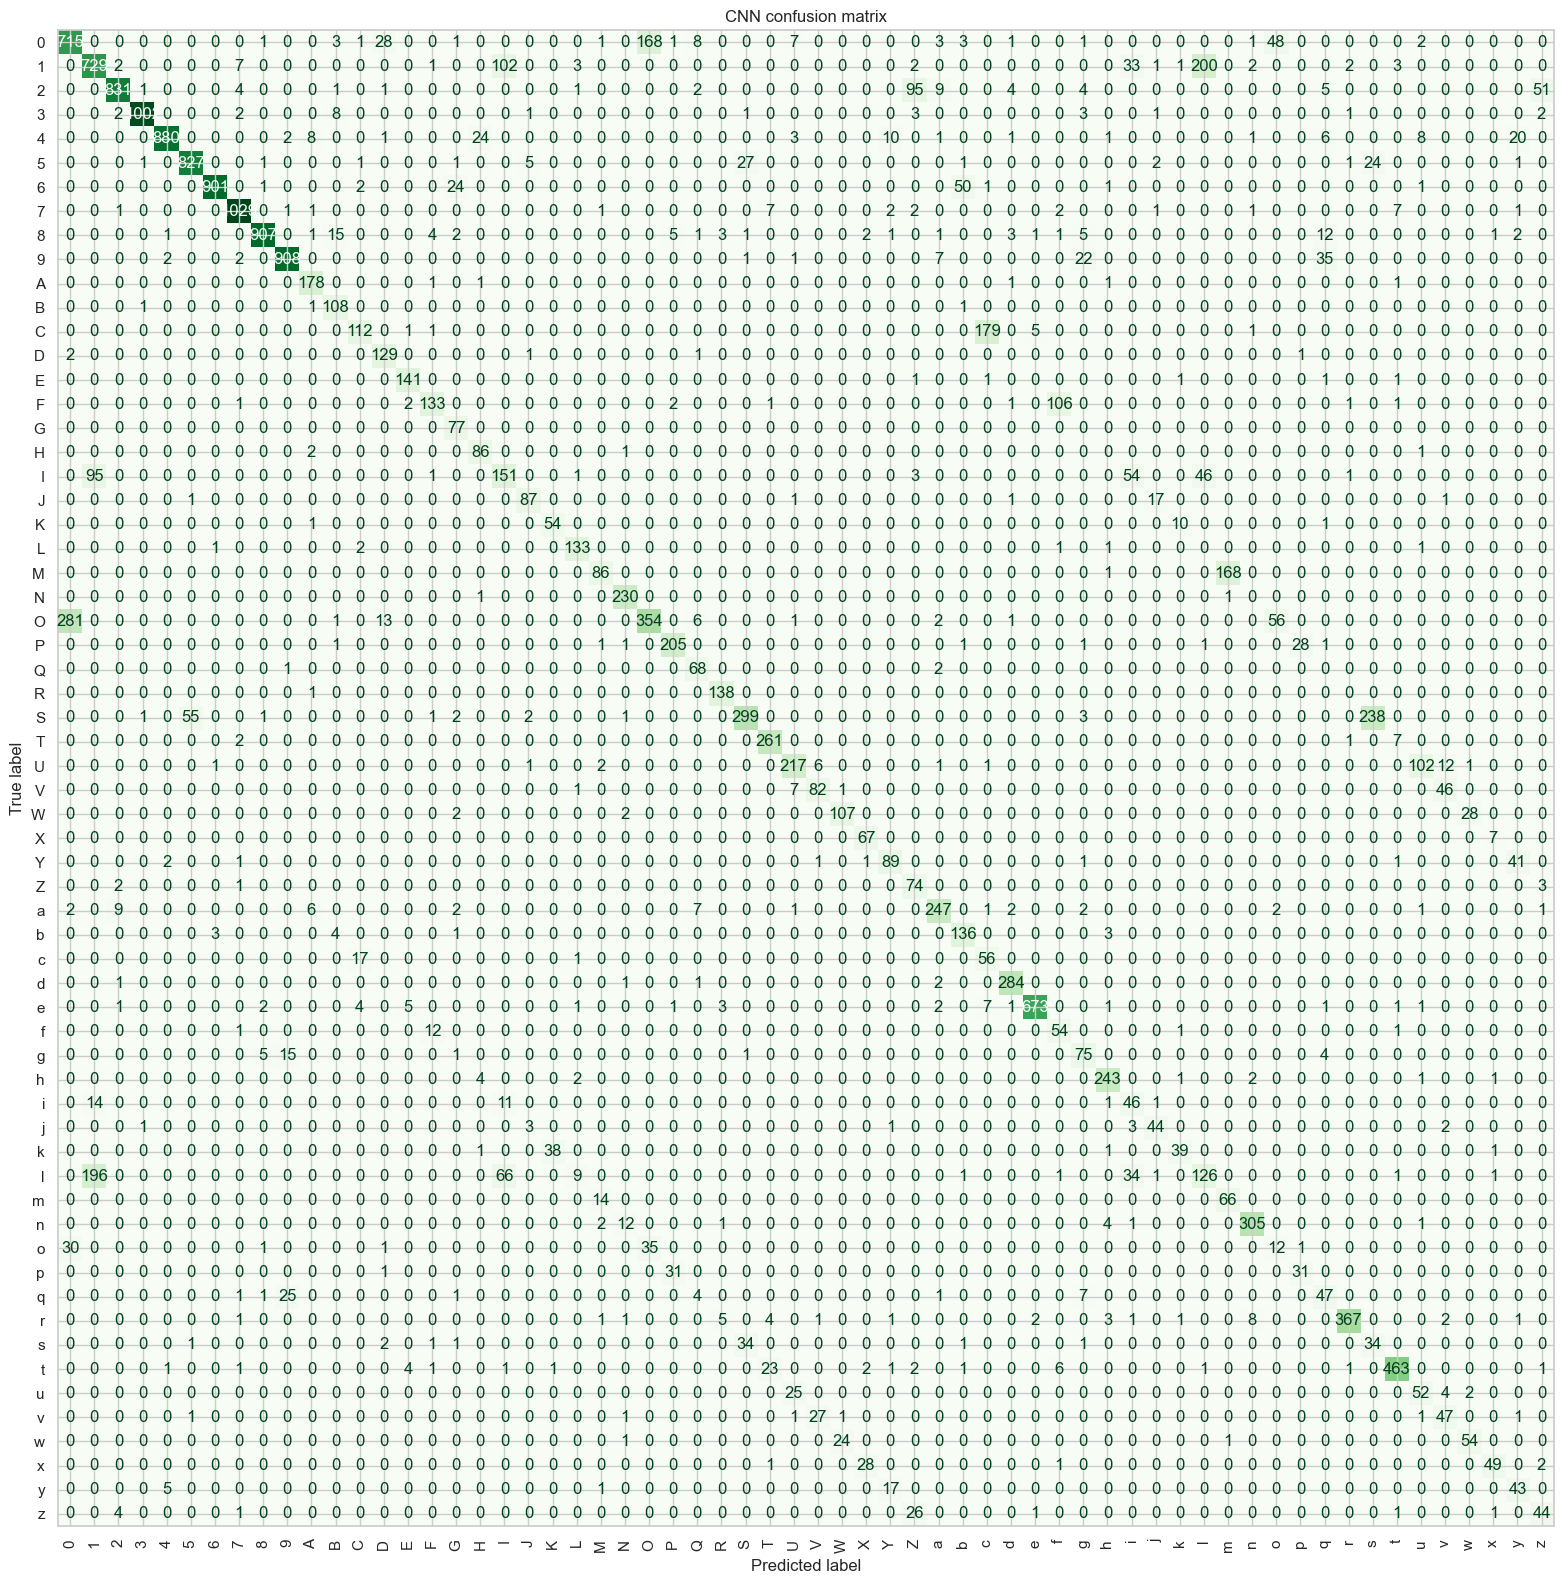

,model,accuracy,f1_macro
0,baseline,0.5046,0.374214
1,cnn,0.8016,0.712752


In [116]:
# Final evaluation on the held-out test split.
cnn_test_proba = cnn.predict(x_test_cnn, batch_size=256, verbose=0)
cnn_test_pred = np.argmax(cnn_test_proba, axis=1)

cnn_metrics = {
    'split': ['test'],
    'accuracy': [accuracy_score(y_test_subset, cnn_test_pred)],
    'precision_macro': [precision_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
    'recall_macro': [recall_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
    'f1_macro': [f1_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
}

display(pd.DataFrame(cnn_metrics))
print(classification_report(y_test_subset, cnn_test_pred, target_names=label_names, zero_division=0))

cm_cnn = confusion_matrix(y_test_subset, cnn_test_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=label_names)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='.0f')
plt.xticks(rotation=90)
plt.title('CNN confusion matrix')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'model': ['baseline', 'cnn'],
    'accuracy': [accuracy_score(y_test_subset, test_baseline_pred), accuracy_score(y_test_subset, cnn_test_pred)],
    'f1_macro': [f1_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0), f1_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
})
display(comparison)


## 10. Error Analysis

Accuracy alone does not tell us where the model struggles. Here we inspect the most common confusions and a sample of misclassified images to understand failure modes and possible improvements.


Top CNN confusions:
O -> 0: 281
S -> s: 238
1 -> l: 200
l -> 1: 196
C -> c: 179
M -> m: 168
0 -> O: 168
F -> f: 106
U -> u: 102
1 -> I: 102
I -> 1: 95
2 -> Z: 95
l -> I: 66
O -> o: 56
S -> 5: 55


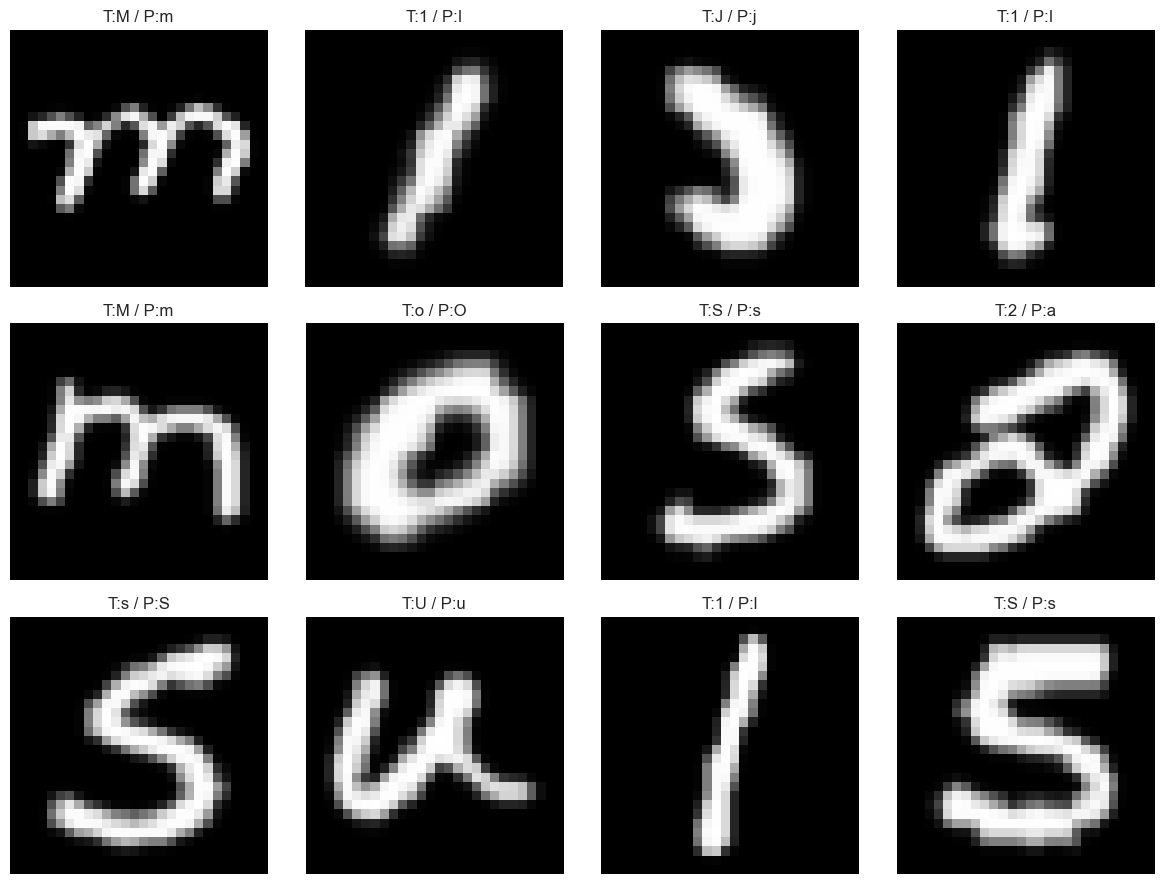

In [95]:
# Error analysis: inspect the most frequent confusions and a few misclassified samples.
def top_confusions(cm, names, top_n=15):
    pairs = []
    for true_idx in range(cm.shape[0]):
        for pred_idx in range(cm.shape[1]):
            if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
                pairs.append((cm[true_idx, pred_idx], names[true_idx], names[pred_idx]))
    return sorted(pairs, reverse=True)[:top_n]


print('Top CNN confusions:')
for count, true_name, pred_name in top_confusions(cm_cnn, label_names):
    print(f'{true_name} -> {pred_name}: {count}')

wrong_idx = np.where(y_test_subset != cnn_test_pred)[0]
if len(wrong_idx) > 0:
    rng = np.random.default_rng(42)
    picks = rng.choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
    cols = 4
    rows = int(np.ceil(len(picks) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, picks):
        ax.imshow(x_test_subset[idx], cmap='gray')
        ax.set_title(f"T:{label_names[int(y_test_subset[idx])]} / P:{label_names[int(cnn_test_pred[idx])]}")
        ax.axis('off')
    for ax in axes[len(picks):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples were found in the selected test subset.')


## 10.1 Integrated Gradients and Occlusion Heatmaps

To better understand how the two models behave, we compare a linear contribution map for the baseline with two more reliable explanation methods for the CNN: Integrated Gradients and occlusion sensitivity.

These methods are less noisy than a raw gradient saliency map and should better highlight the pixels that actually support the character prediction.


[    0     8     9 ... 19987 19990 19993]


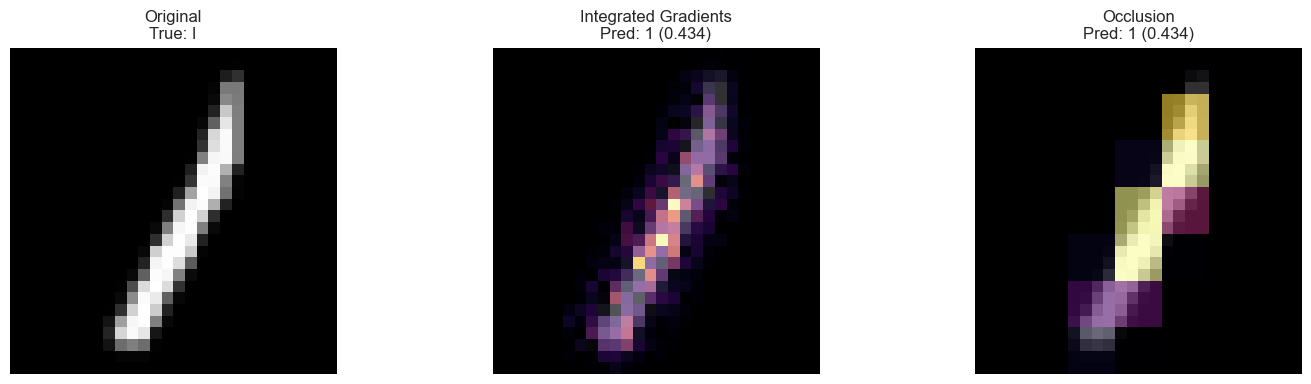

In [106]:
def normalize_map(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    arr -= arr.min()
    if arr.max() > 0:
        arr /= arr.max()
    return arr


def integrated_gradients_map(model, image, class_idx=None, steps=32):
    image = prepare_cnn_input(image)
    baseline = np.zeros_like(image, dtype=np.float32)

    image_tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[None, ...], dtype=tf.float32)
    original_pred = model(image_tensor, training=False)[0]
    if class_idx is None:
        class_idx = int(tf.argmax(original_pred).numpy())

    alphas = tf.linspace(0.0, 1.0, steps + 1)[1:]
    interpolated = baseline_tensor + alphas[:, None, None, None] * (image_tensor - baseline_tensor)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        scores = preds[:, class_idx]

    grads = tape.gradient(scores, interpolated).numpy()
    avg_grads = grads.mean(axis=0)
    ig = np.sum((image - baseline) * avg_grads, axis=-1)
    ig = normalize_map(ig)
    return ig, class_idx, float(original_pred[class_idx].numpy())


def occlusion_map(model, image, class_idx=None, patch_size=4, stride=4):
    image = np.asarray(image, dtype=np.float32)
    base_input = prepare_cnn_input(image)[None, ...]
    base_pred = model(base_input, training=False)[0].numpy()
    if class_idx is None:
        class_idx = int(np.argmax(base_pred))

    base_score = float(base_pred[class_idx])
    masked_images = []
    boxes = []
    h, w = image.shape

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            masked = image.copy()
            masked[y:y2, x:x2] = 0.0
            masked_images.append(prepare_cnn_input(masked))
            boxes.append((y, y2, x, x2))

    masked_batch = np.stack(masked_images)
    masked_preds = model.predict(masked_batch, verbose=0)[:, class_idx]
    heatmap = np.zeros_like(image, dtype=np.float32)
    counts = np.zeros_like(image, dtype=np.float32)

    for score, (y, y2, x, x2) in zip(masked_preds, boxes):
        drop = base_score - float(score)
        heatmap[y:y2, x:x2] += drop
        counts[y:y2, x:x2] += 1.0

    heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts > 0)
    return normalize_map(heatmap), class_idx, base_score


def plot_cnn_explanation(cnn_model, images, labels, names, idx=0):
    ig_map, ig_pred, ig_conf = integrated_gradients_map(cnn_model, images[idx])
    occ_map, occ_pred, occ_conf = occlusion_map(cnn_model, images[idx])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(images[idx], cmap='gray')
    axes[0].set_title(f"Original\nTrue: {names[int(labels[idx])]}")
    axes[0].axis('off')

    axes[1].imshow(images[idx], cmap='gray')
    axes[1].imshow(ig_map, cmap='inferno', alpha=0.6)
    axes[1].set_title(f"Integrated Gradients\nPred: {names[ig_pred]} ({ig_conf:.3f})")
    axes[1].axis('off')

    axes[2].imshow(images[idx], cmap='gray')
    axes[2].imshow(occ_map, cmap='inferno', alpha=0.6)
    axes[2].set_title(f"Occlusion\nPred: {names[occ_pred]} ({occ_conf:.3f})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print(wrong_idx)

sample_idx = int(wrong_idx[0]) if len(wrong_idx) > 0 else 0
plot_cnn_explanation(cnn, x_test_subset, y_test_subset, label_names, idx=sample_idx)


## 10.2 Baseline vs CNN Comparison Gallery

This extra view compares the linear baseline and the CNN on multiple test characters. It helps show whether both models focus on the same strokes, and whether the CNN explanation methods stay centered on the glyph instead of drifting into the background.


Comparison examples: [(1987, '9'), (14679, 't'), (10862, 'W'), (15211, '0'), (9302, '8'), (8625, 'O')]


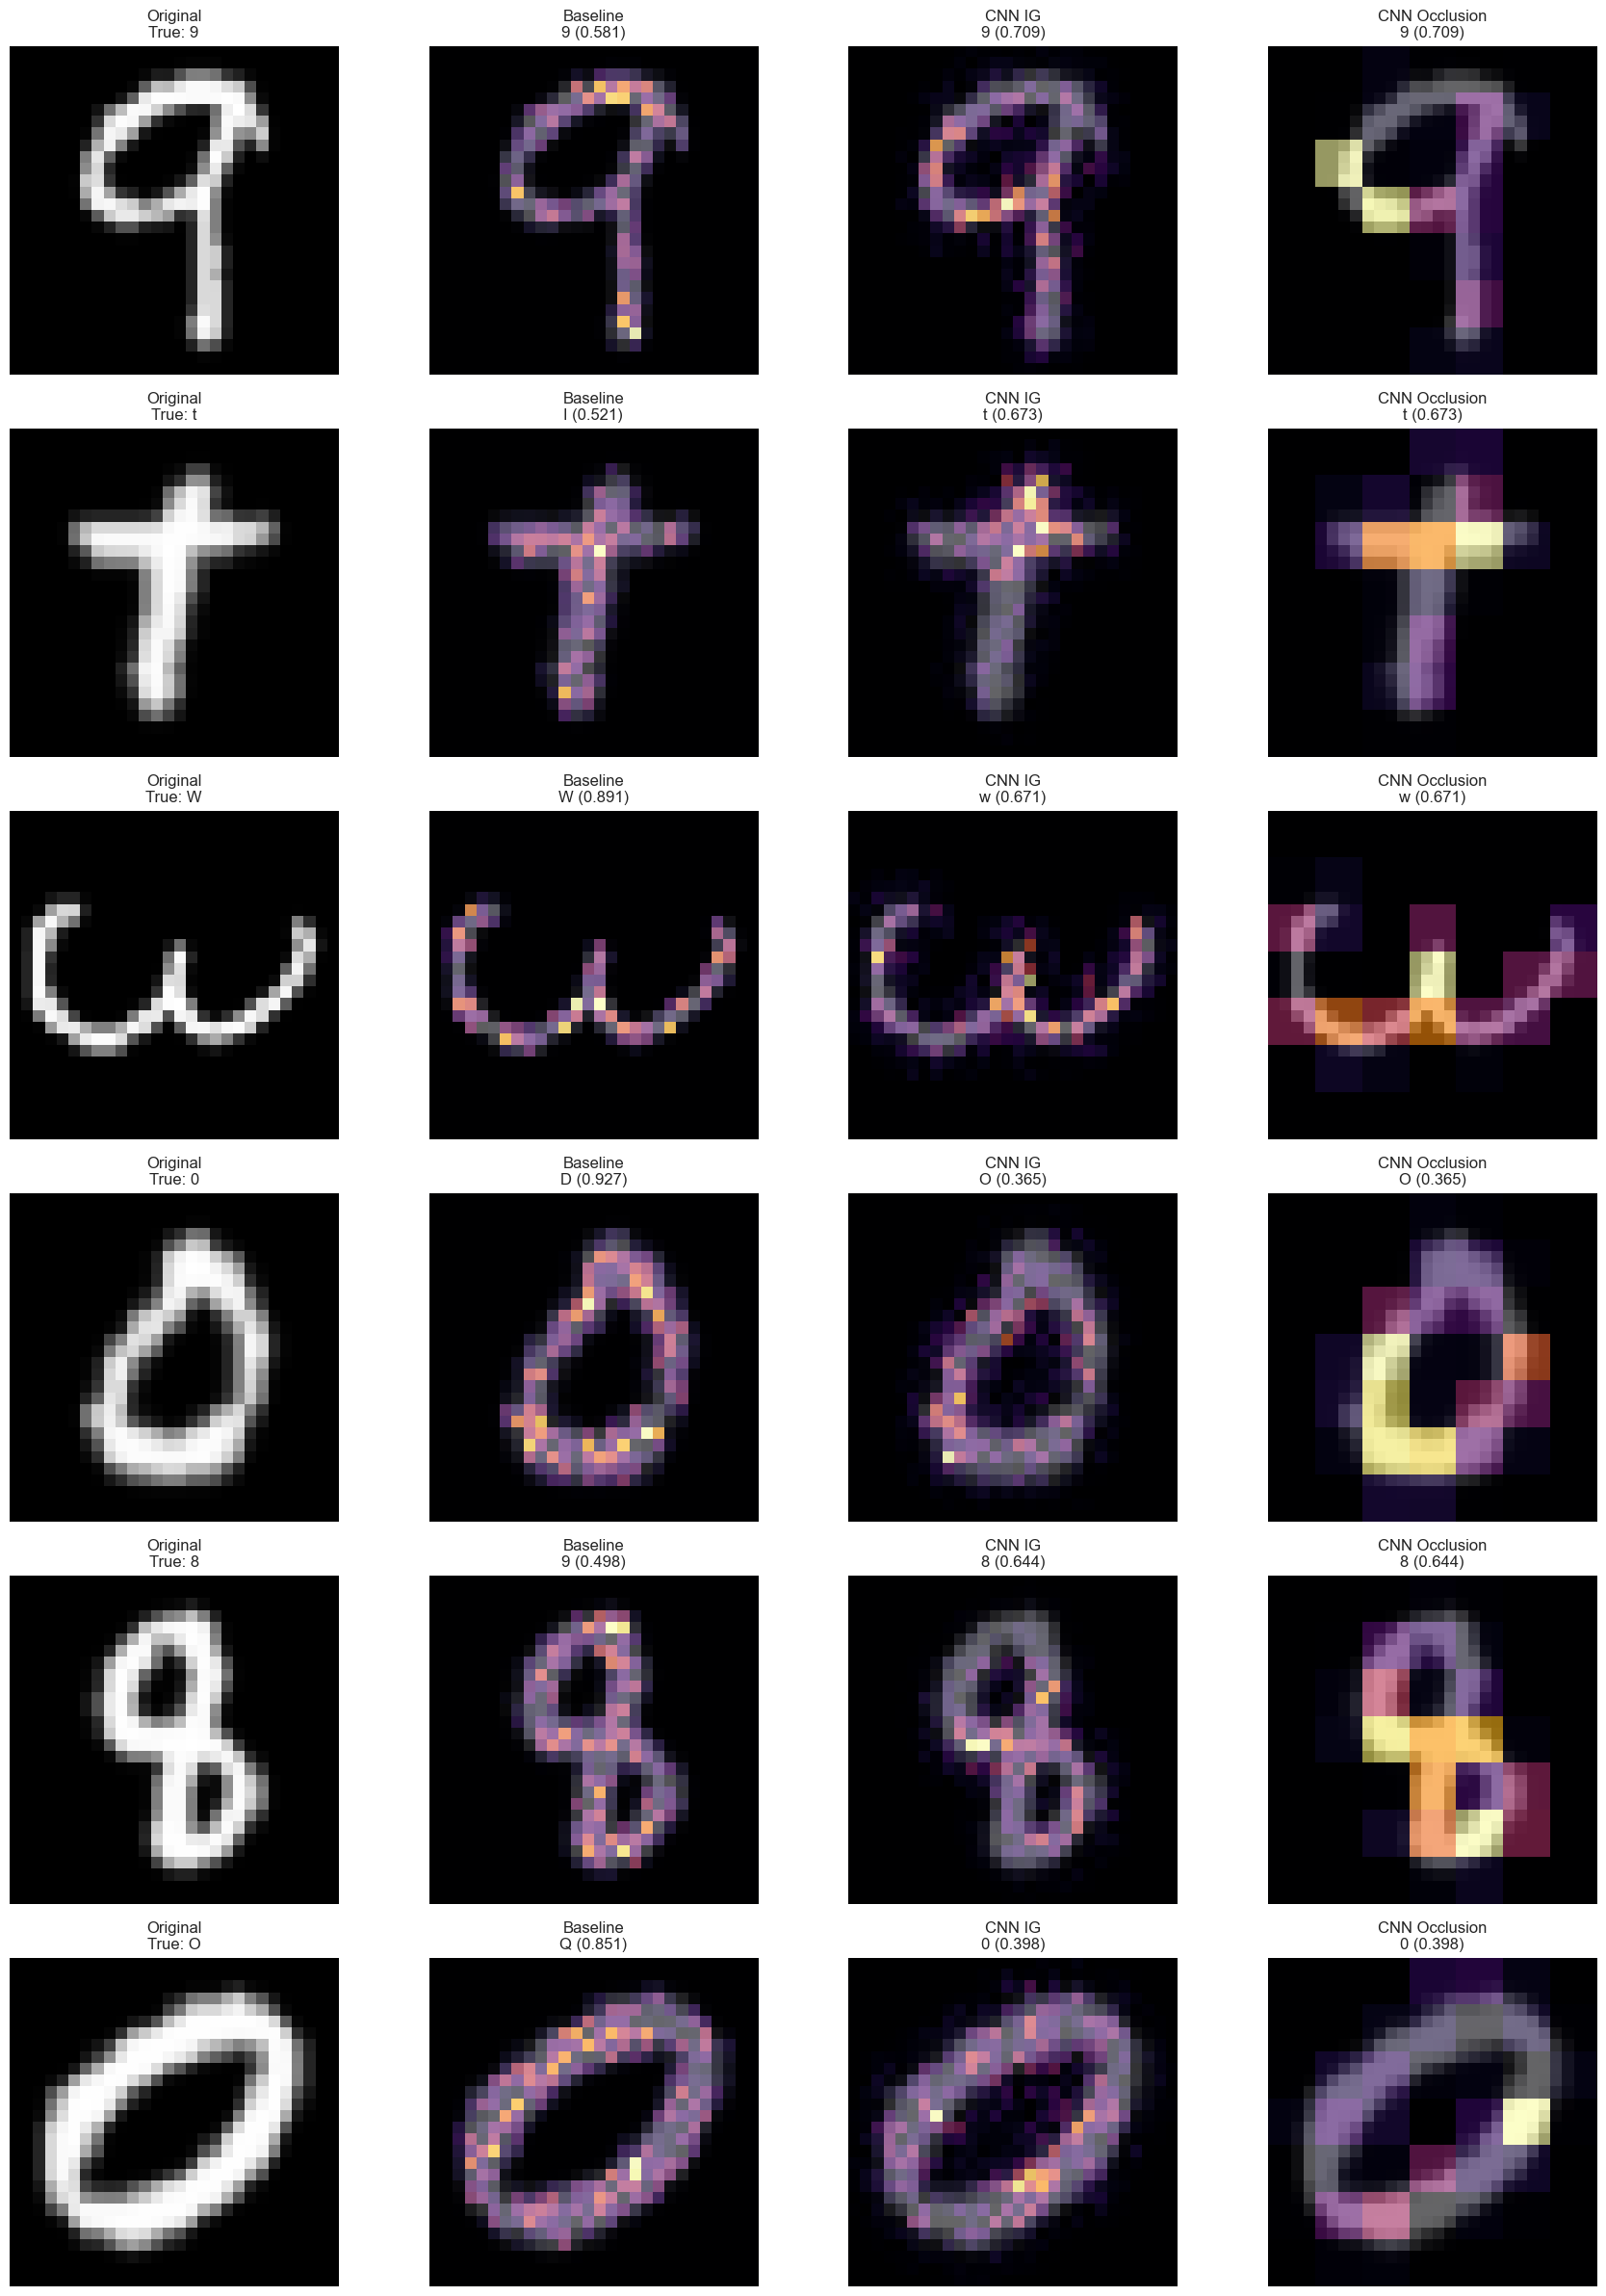

Selected comparison examples:
Index: 1987, True: 9, Baseline: 9 (0.581), CNN: 9 (0.709)
Index: 14679, True: t, Baseline: I (0.521), CNN: t (0.673)
Index: 10862, True: W, Baseline: W (0.891), CNN: w (0.671)
Index: 15211, True: 0, Baseline: D (0.927), CNN: O (0.365)
Index: 9302, True: 8, Baseline: 9 (0.498), CNN: 8 (0.644)
Index: 8625, True: O, Baseline: Q (0.851), CNN: 0 (0.398)


In [114]:
def normalize_map(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    arr -= arr.min()
    if arr.max() > 0:
        arr /= arr.max()
    return arr


def baseline_saliency_map(model, image, class_idx=None):
    image = np.asarray(image, dtype=np.float32)
    flat = image.reshape(-1)
    proba = model.predict_proba(flat[np.newaxis, :])[0]
    if class_idx is None:
        class_idx = int(np.argmax(proba))
    contrib = np.abs(model.coef_[class_idx] * flat).reshape(image.shape)
    return normalize_map(contrib), class_idx, float(proba[class_idx])


def integrated_gradients_map(model, image, class_idx=None, steps=32):
    image = prepare_cnn_input(image)
    baseline = np.zeros_like(image, dtype=np.float32)
    image_tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[None, ...], dtype=tf.float32)
    original_pred = model(image_tensor, training=False)[0]
    if class_idx is None:
        class_idx = int(tf.argmax(original_pred).numpy())

    alphas = tf.linspace(0.0, 1.0, steps + 1)[1:]
    interpolated = baseline_tensor + alphas[:, None, None, None] * (image_tensor - baseline_tensor)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        scores = preds[:, class_idx]

    grads = tape.gradient(scores, interpolated).numpy()
    avg_grads = grads.mean(axis=0)
    ig = np.sum((image - baseline) * avg_grads, axis=-1)
    return normalize_map(ig), class_idx, float(original_pred[class_idx].numpy())


def occlusion_map(model, image, class_idx=None, patch_size=4, stride=4):
    image = np.asarray(image, dtype=np.float32)
    base_input = prepare_cnn_input(image)[None, ...]
    base_pred = model(base_input, training=False)[0].numpy()
    if class_idx is None:
        class_idx = int(np.argmax(base_pred))

    base_score = float(base_pred[class_idx])
    masked_images = []
    boxes = []
    h, w = image.shape

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            masked = image.copy()
            masked[y:y2, x:x2] = 0.0
            masked_images.append(prepare_cnn_input(masked))
            boxes.append((y, y2, x, x2))

    masked_batch = np.stack(masked_images)
    masked_preds = model.predict(masked_batch, verbose=0)[:, class_idx]
    heatmap = np.zeros_like(image, dtype=np.float32)
    counts = np.zeros_like(image, dtype=np.float32)

    for score, (y, y2, x, x2) in zip(masked_preds, boxes):
        drop = base_score - float(score)
        heatmap[y:y2, x:x2] += drop
        counts[y:y2, x:x2] += 1.0

    heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts > 0)
    return normalize_map(heatmap), class_idx, base_score


def pick_example_indices(y_true, baseline_pred, cnn_pred, n=4, seed=1):
    rng = np.random.default_rng(seed)
    pools = [
        np.where((y_true == baseline_pred) & (y_true == cnn_pred))[0],
        np.where((y_true != baseline_pred) & (y_true == cnn_pred))[0],
        np.where((y_true == baseline_pred) & (y_true != cnn_pred))[0],
        np.where((y_true != baseline_pred) & (y_true != cnn_pred))[0],
    ]
    picked = []
    for pool in pools:
        if len(pool) == 0:
            continue
        picked.append(int(rng.choice(pool)))
        if len(picked) >= n:
            break
    if len(picked) < n:
        remaining = np.setdiff1d(np.arange(len(y_true)), np.array(picked, dtype=int), assume_unique=False)
        if len(remaining) > 0:
            extra = rng.choice(remaining, size=min(n - len(picked), len(remaining)), replace=False)
            picked.extend([int(i) for i in extra])
    return picked[:n]


def plot_comparison_gallery(baseline_model, cnn_model, images, labels, names, indices):
    rows = len(indices)
    fig, axes = plt.subplots(rows, 4, figsize=(18, 4 * rows))
    if rows == 1:
        axes = np.array([axes])

    for row, idx in enumerate(indices):
        base_map, base_pred, base_conf = baseline_saliency_map(baseline_model, images[idx])
        ig_map, ig_pred, ig_conf = integrated_gradients_map(cnn_model, images[idx])
        occ_map, occ_pred, occ_conf = occlusion_map(cnn_model, images[idx])

        ax = axes[row, 0]
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"Original\nTrue: {names[int(labels[idx])]}")
        ax.axis('off')

        ax = axes[row, 1]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(base_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"Baseline\n{names[base_pred]} ({base_conf:.3f})")
        ax.axis('off')

        ax = axes[row, 2]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(ig_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"CNN IG\n{names[ig_pred]} ({ig_conf:.3f})")
        ax.axis('off')

        ax = axes[row, 3]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(occ_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"CNN Occlusion\n{names[occ_pred]} ({occ_conf:.3f})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


comparison_indices = pick_example_indices(y_test_subset, test_baseline_pred, cnn_test_pred, n=6, seed=47)
print('Comparison examples:', [(idx, label_names[int(y_test_subset[idx])]) for idx in comparison_indices])
plot_comparison_gallery(baseline, cnn, x_test_subset, y_test_subset, label_names, comparison_indices)


print('Selected comparison examples:')
for idx in comparison_indices:
    baseline_conf = baseline.predict_proba(x_test_flat[idx].reshape(1, -1))[0][test_baseline_pred[idx]]
    cnn_conf = cnn_test_proba[idx][cnn_test_pred[idx]]
    print(
        f'Index: {idx}, True: {label_names[int(y_test_subset[idx])]}, '
        f'Baseline: {label_names[int(test_baseline_pred[idx])]} ({baseline_conf:.3f}), '
        f'CNN: {label_names[int(cnn_test_pred[idx])]} ({cnn_conf:.3f})')


## 11. Interactive Drawing Demo

The function defined below opens a small drawing window for manual testing. Draw a character, run prediction, and compare the result against the model output. This is a lightweight way to demonstrate the end-to-end OCR pipeline.

The drawn image is resized to `28 x 28` and inverted before prediction so it matches the training format.


In [115]:
def launch_drawing_app(model, names):
    try:
        import tkinter as tk
        from tkinter import messagebox
        from PIL import Image, ImageDraw, ImageOps
    except Exception as exc:
        print('Drawing window unavailable in this environment:', exc)
        return

    canvas_size = 280
    brush_size = 18
    bg_color = 'white'
    pen_color = 'black'

    root = tk.Tk()
    root.title('OCR Drawing Test')
    root.resizable(False, False)

    info = tk.Label(
        root,
        text='Draw a character, then click Predict. Use Clear to reset the canvas.',
        padx=10,
        pady=8,
    )
    info.pack()

    canvas = tk.Canvas(root, width=canvas_size, height=canvas_size, bg=bg_color, cursor='cross')
    canvas.pack(padx=10, pady=10)

    image = Image.new('L', (canvas_size, canvas_size), 255)
    draw = ImageDraw.Draw(image)
    last_x, last_y = None, None

    result_var = tk.StringVar(value='Prediction will appear here.')
    result_label = tk.Label(root, textvariable=result_var, font=('Arial', 14, 'bold'), pady=8)
    result_label.pack()

    button_frame = tk.Frame(root)
    button_frame.pack(pady=8)

    def paint(event):
        nonlocal last_x, last_y
        x, y = event.x, event.y
        if last_x is not None and last_y is not None:
            canvas.create_line(last_x, last_y, x, y, fill=pen_color, width=brush_size, capstyle=tk.ROUND, smooth=True)
            draw.line((last_x, last_y, x, y), fill=0, width=brush_size)
        last_x, last_y = x, y

    def reset(_event=None):
        nonlocal image, draw, last_x, last_y
        canvas.delete('all')
        canvas.configure(bg=bg_color)
        image = Image.new('L', (canvas_size, canvas_size), 255)
        draw = ImageDraw.Draw(image)
        last_x, last_y = None, None
        result_var.set('Prediction will appear here.')

    def predict():
        # Invert because the model was trained on dark backgrounds with bright strokes.
        img = image.copy()
        img = ImageOps.invert(img)
        img = img.resize((28, 28))
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = prepare_cnn_input(arr)[None, ...]
        probs = model.predict(arr, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_name = names[pred_idx]
        confidence = float(probs[pred_idx])
        result_var.set(f'Prediction: {pred_name}  |  confidence: {confidence:.3f}')

    def on_release(_event):
        nonlocal last_x, last_y
        last_x, last_y = None, None

    canvas.bind('<B1-Motion>', paint)
    canvas.bind('<ButtonRelease-1>', on_release)

    tk.Button(button_frame, text='Predict', width=14, command=predict).grid(row=0, column=0, padx=8)
    tk.Button(button_frame, text='Clear', width=14, command=reset).grid(row=0, column=1, padx=8)
    tk.Button(button_frame, text='Quit', width=14, command=root.destroy).grid(row=0, column=2, padx=8)

    root.bind('<Escape>', lambda _event: root.destroy())
    root.bind('c', reset)
    root.bind('p', lambda _event: predict())
    root.mainloop()


# Launch the drawing window.
launch_drawing_app(cnn, label_names)


## 12. Model Diagnostics

This section extracts useful internals from the CNN and builds extra figures for the report: weight summaries, weight histograms, first-layer filters, per-class recall, and a few confident predictions.


,layer,tensor,shape,n_params,mean,std,min,max
0,conv2d,w0,"(3, 3, 2, 32)",576,-0.002283,0.094991,-0.241397,0.210431
1,batch_normalization,w0,"(32,)",32,0.935028,0.115536,0.591588,1.153704
2,batch_normalization,w1,"(32,)",32,-0.301736,0.130355,-0.513289,-0.043691
3,batch_normalization,w2,"(32,)",32,-0.020174,0.041296,-0.105615,0.128798
4,batch_normalization,w3,"(32,)",32,0.007336,0.005716,0.000457,0.031351
5,conv2d_1,w0,"(3, 3, 32, 64)",18432,-0.007682,0.070570,-0.389720,0.269762
6,batch_normalization_1,w0,"(64,)",64,0.967213,0.071081,0.820005,1.177291
7,batch_normalization_1,w1,"(64,)",64,-0.279988,0.075614,-0.432547,-0.136471
8,batch_normalization_1,w2,"(64,)",64,-0.492999,0.422097,-1.311825,1.009796
9,batch_normalization_1,w3,"(64,)",64,1.113832,0.350322,0.549521,2.330830


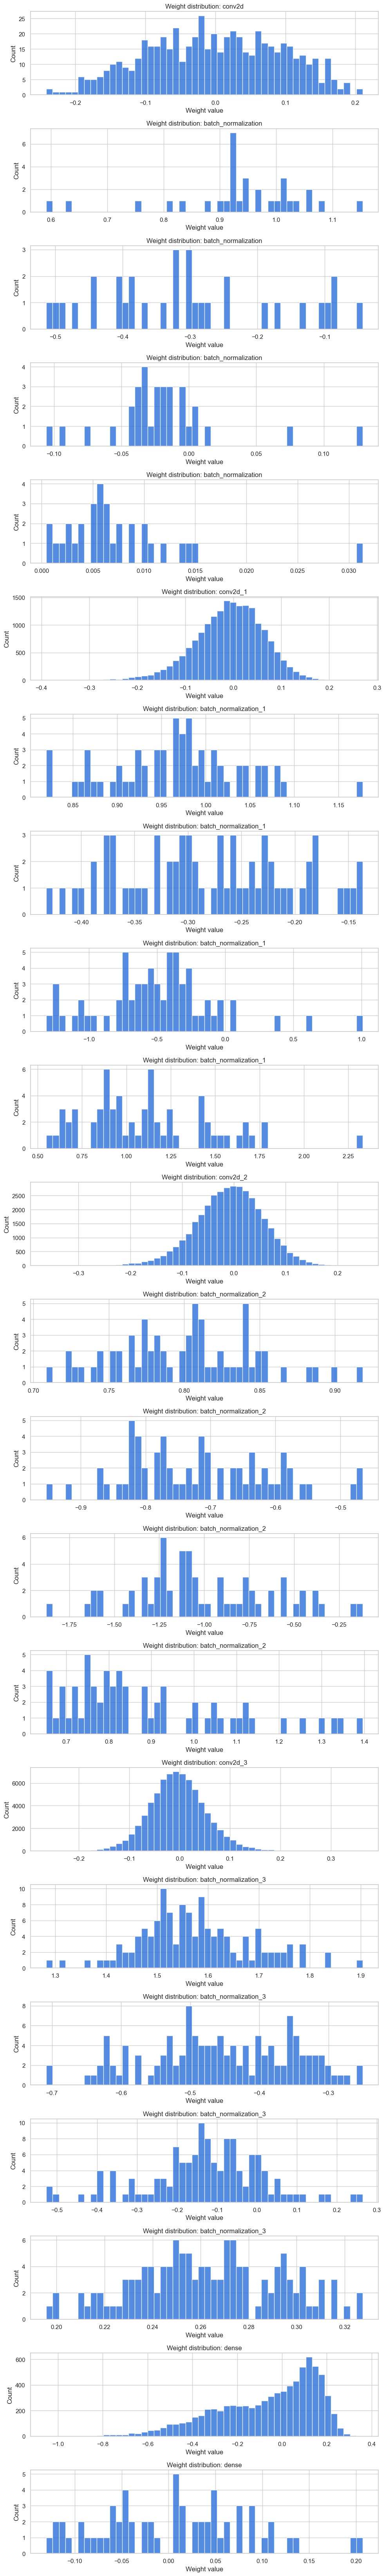

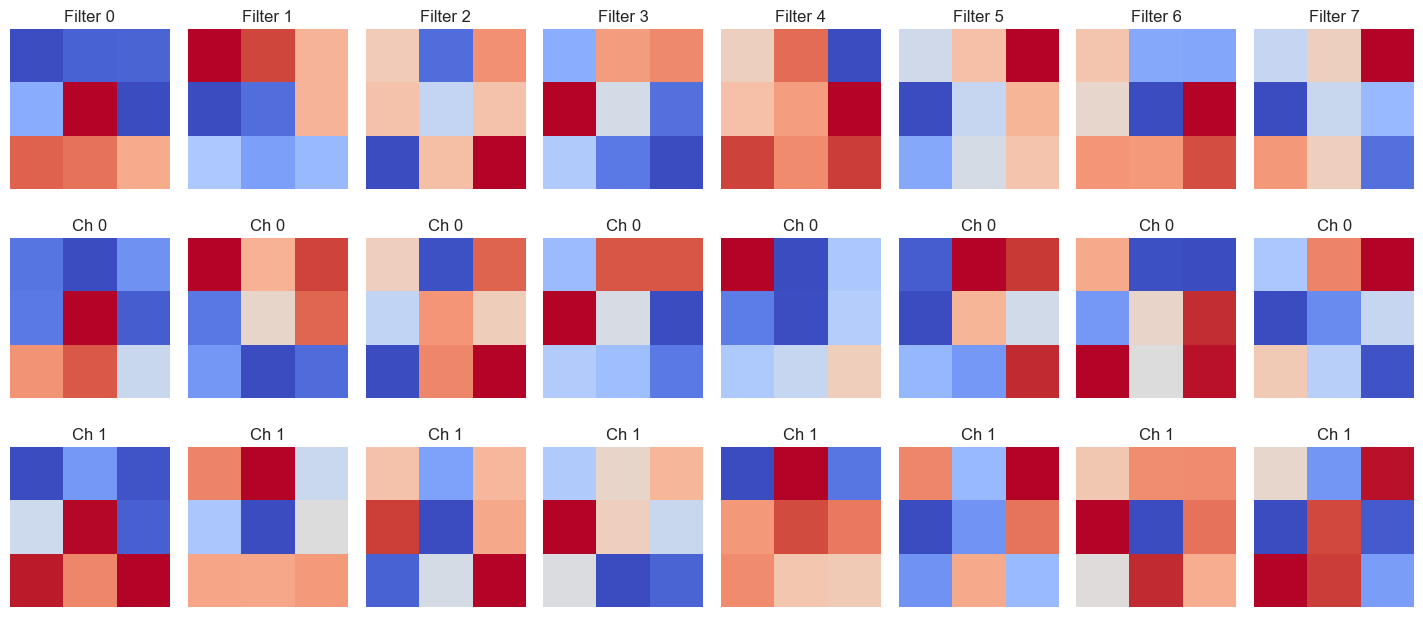

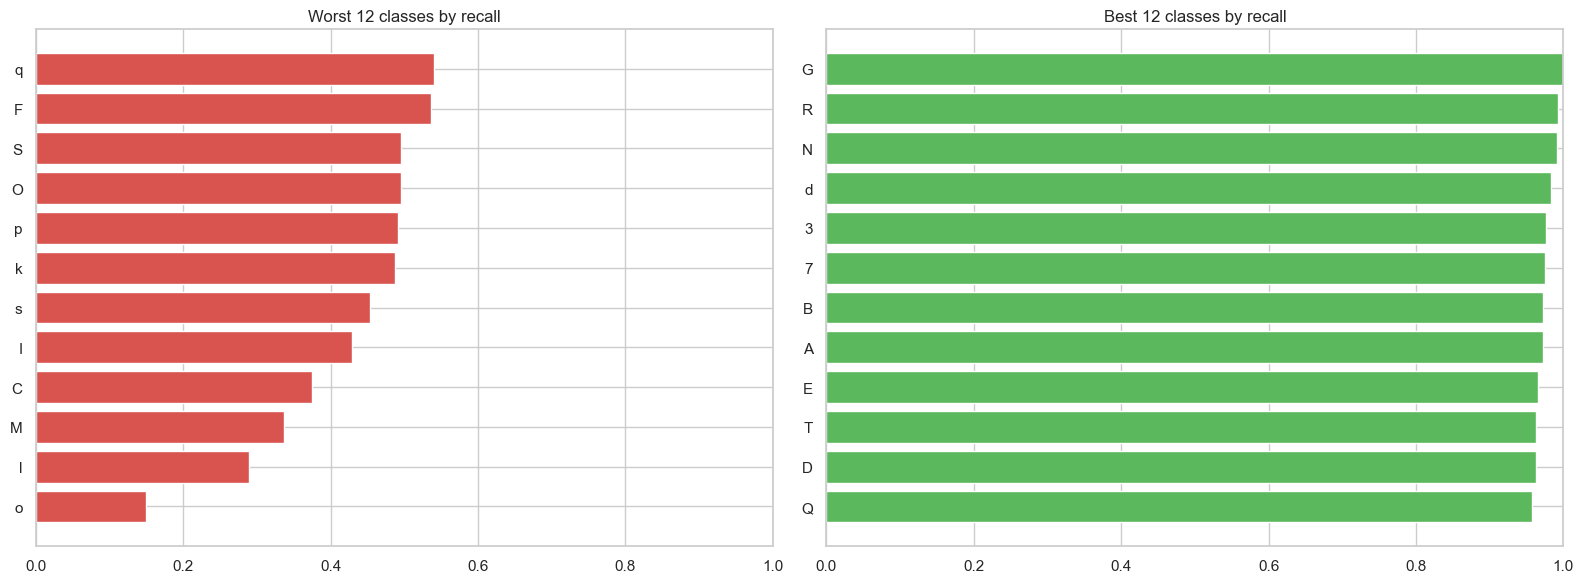

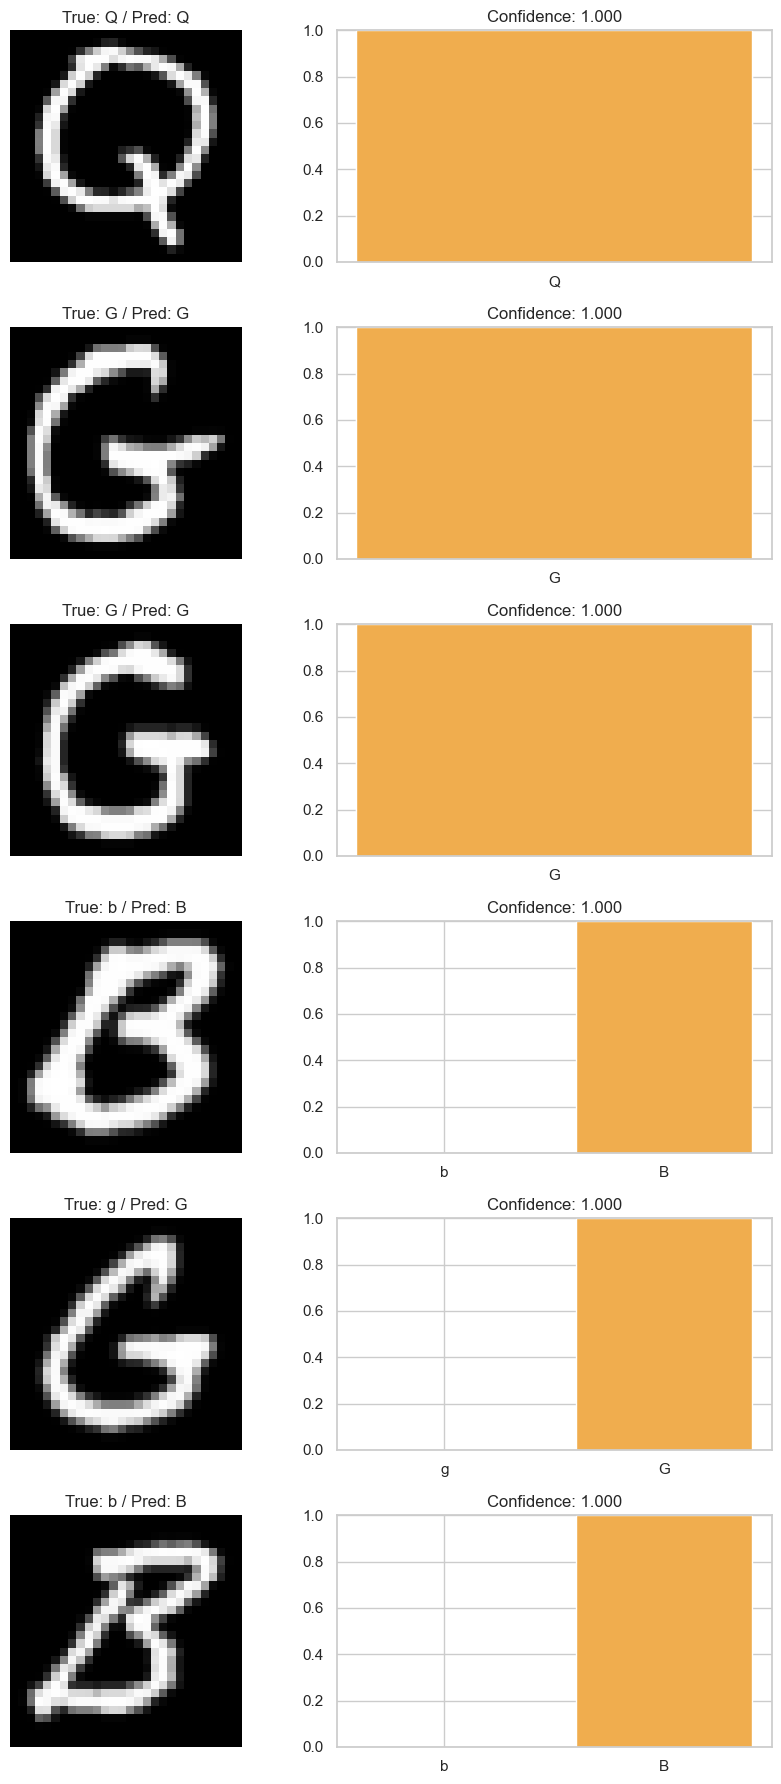

In [104]:
def summarize_cnn_weights(model):
    rows = []
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        for idx, arr in enumerate(weights):
            arr = np.asarray(arr)
            rows.append({
                'layer': layer.name,
                'tensor': f'w{idx}',
                'shape': str(arr.shape),
                'n_params': int(arr.size),
                'mean': float(arr.mean()),
                'std': float(arr.std()),
                'min': float(arr.min()),
                'max': float(arr.max()),
            })
    return pd.DataFrame(rows)


def plot_weight_histograms(model):
    weight_blocks = []
    for layer in model.layers:
        for arr in layer.get_weights():
            arr = np.asarray(arr).ravel()
            if arr.size > 0:
                weight_blocks.append((layer.name, arr))

    if not weight_blocks:
        print('No trainable weights found.')
        return

    fig, axes = plt.subplots(len(weight_blocks), 1, figsize=(10, 3 * len(weight_blocks)))
    if len(weight_blocks) == 1:
        axes = [axes]
    for ax, (layer_name, values) in zip(axes, weight_blocks):
        ax.hist(values, bins=50, color='#2a6fdb', alpha=0.8)
        ax.set_title(f'Weight distribution: {layer_name}')
        ax.set_xlabel('Weight value')
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


def plot_first_conv_filters(model, max_filters=8):
    conv_layer = next((layer for layer in model.layers if isinstance(layer, keras.layers.Conv2D)), None)
    if conv_layer is None:
        print('No Conv2D layer found.')
        return

    kernel = conv_layer.get_weights()[0]
    n_filters = min(kernel.shape[-1], max_filters)
    n_channels = kernel.shape[2]
    fig, axes = plt.subplots(n_channels + 1, n_filters, figsize=(1.8 * n_filters, 2.2 * (n_channels + 1)))
    if n_filters == 1:
        axes = np.expand_dims(axes, axis=1)

    for f in range(n_filters):
        combined = kernel[:, :, :, f].mean(axis=2)
        axes[0, f].imshow(combined, cmap='coolwarm')
        axes[0, f].set_title(f'Filter {f}')
        axes[0, f].axis('off')
        for c in range(n_channels):
            axes[c + 1, f].imshow(kernel[:, :, c, f], cmap='coolwarm')
            axes[c + 1, f].set_title(f'Ch {c}')
            axes[c + 1, f].axis('off')

    plt.tight_layout()
    plt.show()


def plot_per_class_recall(cm, names, top_n=12):
    per_class = np.divide(np.diag(cm), cm.sum(axis=1), out=np.zeros(cm.shape[0], dtype=float), where=cm.sum(axis=1) > 0)
    order = np.argsort(per_class)
    worst = order[:top_n]
    best = order[-top_n:][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].barh([names[i] for i in worst], per_class[worst], color='#d9534f')
    axes[0].set_title(f'Worst {top_n} classes by recall')
    axes[0].set_xlim(0, 1)

    axes[1].barh([names[i] for i in best[::-1]], per_class[best[::-1]], color='#5cb85c')
    axes[1].set_title(f'Best {top_n} classes by recall')
    axes[1].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def plot_confident_examples(images, labels, preds, proba, names, n=6):
    confidence = proba.max(axis=1)
    correct = np.where(preds == labels)[0]
    wrong = np.where(preds != labels)[0]
    picks = []
    if len(correct) > 0:
        picks.extend(correct[np.argsort(confidence[correct])[-min(3, len(correct)):]][::-1].tolist())
    if len(wrong) > 0:
        picks.extend(wrong[np.argsort(confidence[wrong])[-min(3, len(wrong)):]][::-1].tolist())
    picks = picks[:n]

    rows = len(picks)
    fig, axes = plt.subplots(rows, 2, figsize=(9, 3 * rows))
    if rows == 1:
        axes = np.array([axes])

    for row, idx in enumerate(picks):
        axes[row, 0].imshow(images[idx], cmap='gray')
        axes[row, 0].axis('off')
        axes[row, 0].set_title(f'True: {names[int(labels[idx])]} / Pred: {names[int(preds[idx])]}')

        classes = [names[int(labels[idx])], names[int(preds[idx])]]
        values = [float(proba[idx, labels[idx]]), float(confidence[idx])]
        axes[row, 1].bar(classes, values, color=['#5bc0de', '#f0ad4e'])
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].set_title(f'Confidence: {confidence[idx]:.3f}')

    plt.tight_layout()
    plt.show()


weights_df = summarize_cnn_weights(cnn)
display(weights_df)
plot_weight_histograms(cnn)
plot_first_conv_filters(cnn, max_filters=8)
plot_per_class_recall(cm_cnn, label_names, top_n=12)
plot_confident_examples(x_test_subset, y_test_subset, cnn_test_pred, cnn_test_proba, label_names, n=6)


## 13. Report Notes

Use this notebook as the technical backbone of the written report. The most relevant points to discuss are:

- the dataset format and class distribution
- examples of preprocessed handwritten characters
- why normalization, reshaping, and validation splitting are necessary
- the difference between the baseline classifier and the CNN
- the most important confusions shown by the error analysis
- limitations of the current model and realistic next steps such as augmentation, deeper architectures, or language-model post-processing
